# 03 - Modelado
Comparo varios modelos, reviso curvas de aprendizaje y validación, hago tuning ligero y un stacking final. Métricas clave: ROC AUC, F1, Recall.


In [1]:
# Carga dataset preparado (sin JSON meta ni transformaciones adicionales)
import pandas as pd, numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             balanced_accuracy_score, average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET_COL = 'RainTomorrow'
processed_dir = Path('../data/processed')
prepared_csv = processed_dir / 'weather_prepared_selected.csv'

full_df = pd.read_csv(prepared_csv)

# Columnas de modelado = todas menos la target
feature_columns = [c for c in full_df.columns if c != TARGET_COL]
print('Total columnas disponibles para modelado:', len(feature_columns))

y_full = full_df[TARGET_COL].astype(int)
X_full = full_df[feature_columns].copy()

# Splits estratificados Train 60% / Valid 20% / Test 20%
X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print('Shapes -> Train:', X_train.shape, 'Valid:', X_valid.shape, 'Test:', X_test.shape)

Total columnas disponibles para modelado: 25
Shapes -> Train: (85315, 25) Valid: (28439, 25) Test: (28439, 25)


In [2]:
# Helpers y Configuración Global de Métricas / Preprocesamiento
from sklearn.model_selection import learning_curve, StratifiedKFold
from pathlib import Path

def build_preprocessor(X_fit: pd.DataFrame):
    num_cols_local = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols_local = X_fit.select_dtypes(exclude=[np.number]).columns.tolist()
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))])
    return ColumnTransformer([
        ('num', num_pipe, num_cols_local),
        ('cat', cat_pipe, cat_cols_local)
    ])

# Métricas auxiliares
def metricas_basicas(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, proba),
        'pr_auc': average_precision_score(y_true, proba),
        'f1': f1_score(y_true, pred),
        'recall': recall_score(y_true, pred),
        'precision': precision_score(y_true, pred),
        'bal_acc': balanced_accuracy_score(y_true, pred)
    }

# Guardado de figuras
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, tight=True, dpi=120):
    """Guarda la figura matplotlib activa en PNG dentro de reports/figures."""
    if tight:
        plt.tight_layout()
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=dpi)
    print(f"Figura guardada: {path}")

# Función general para curvas de aprendizaje sklearn
def plot_learning_curve(estimator, X, y, *, cv=None, train_sizes=None, scoring='roc_auc', title='', fig_name=None, random_state=42):
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    if train_sizes is None:
        train_sizes = np.linspace(0.15, 1.0, 7)
    tr_sizes, tr_scores, va_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=train_sizes,
        shuffle=True,
        random_state=random_state
    )
    tr_mean = tr_scores.mean(axis=1); tr_std = tr_scores.std(axis=1)
    va_mean = va_scores.mean(axis=1); va_std = va_scores.std(axis=1)
    plt.figure(figsize=(6,4))
    plt.plot(tr_sizes, tr_mean, marker='o', label='Train AUC')
    plt.fill_between(tr_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15)
    plt.plot(tr_sizes, va_mean, marker='o', label='CV AUC')
    plt.fill_between(tr_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15)
    plt.xlabel('N muestras entrenamiento')
    plt.ylabel('ROC AUC')
    plt.title(title or 'Curva de aprendizaje')
    plt.legend();
    if fig_name:
        save_fig(fig_name)
    plt.show()
    return {'train_sizes': tr_sizes, 'train_mean': tr_mean, 'val_mean': va_mean}

IMPROVEMENT_MIN = 0.005  # Incremento mínimo de AUC válido para justificar aumentar complejidad
OVERFIT_GAP_MAX = 0.04   # Diferencia máxima (train - valid AUC) tolerada antes de considerar sobreajuste

print(f"IMPROVEMENT_MIN={IMPROVEMENT_MIN} | OVERFIT_GAP_MAX={OVERFIT_GAP_MAX}")

# Explicación rápida:
print("IMPROVEMENT_MIN: evita escalar modelos por mejoras marginales (<0.005 AUC).")
print("OVERFIT_GAP_MAX: descarta modelos cuyo desempeño en train supera demasiado al de valid (gap > 0.04).")

IMPROVEMENT_MIN=0.005 | OVERFIT_GAP_MAX=0.04
IMPROVEMENT_MIN: evita escalar modelos por mejoras marginales (<0.005 AUC).
OVERFIT_GAP_MAX: descarta modelos cuyo desempeño en train supera demasiado al de valid (gap > 0.04).


In [3]:
# Etapa 1: Evaluación inicial (LogisticRegression con estrategias de balanceo) – simplificada
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
preprocessor = build_preprocessor(pd.concat([X_train, X_valid]))

# Modelos evaluados SOLO en esta etapa (para decidir si vale la pena balancear)

logit_plain = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=400))
])
logit_bal = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=400, class_weight='balanced'))
])
logit_smote = ImbPipeline([
    ('prep', build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)),
    ('clf', LogisticRegression(max_iter=400))
])
dummy = Pipeline([
    ('prep', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent'))
])

candidates_imb = {
    'dummy': dummy,
    'logit_plain': logit_plain,
    'logit_bal': logit_bal,
    'logit_smote': logit_smote
}

imbalance_results = {}
for name, pipe in candidates_imb.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring='roc_auc', return_train_score=True, n_jobs=-1)
    mean_train = cv_res['train_score'].mean()
    mean_valid = cv_res['test_score'].mean()
    gap = mean_train - mean_valid
    imbalance_results[name] = {'train_auc': mean_train, 'valid_auc': mean_valid, 'gap': gap}

print('Resultados estrategia (ROC AUC):')
for k,v in imbalance_results.items():
    print(f"{k}: train={v['train_auc']:.4f} valid={v['valid_auc']:.4f} gap={v['gap']:.4f}")

# Selección: mejor valid con gap aceptable
valid_sorted = sorted(imbalance_results.items(), key=lambda kv: kv[1]['valid_auc'], reverse=True)
chosen_name = None
for nm, vals in valid_sorted:
    if vals['gap'] <= OVERFIT_GAP_MAX:
        chosen_name = nm
        break
if chosen_name is None:
    chosen_name = min(imbalance_results.items(), key=lambda kv: kv[1]['gap'])[0]

chosen_imbalance_strategy = chosen_name
print('\nEstrategia elegida para continuar (solo se aplicará esa en adelante):', chosen_imbalance_strategy)

baseline_pipeline = candidates_imb[chosen_imbalance_strategy]
baseline_cv_auc = imbalance_results[chosen_imbalance_strategy]['valid_auc']
baseline_gap = imbalance_results[chosen_imbalance_strategy]['gap']

# Flag para etapas siguientes
USE_BALANCING_LATER = (chosen_imbalance_strategy != 'logit_plain')
if not USE_BALANCING_LATER:
    print('Se continuará SIN class_weight ni SMOTE en modelos posteriores para ahorrar tiempo.')
else:
    print('Se permitirá uso de balanceo en modelos más complejos.')

model_trace = []
model_trace.append({'stage': 'baseline', 'model': chosen_imbalance_strategy, 'valid_auc': baseline_cv_auc, 'gap': baseline_gap})
print(f'Baseline elegido: {chosen_imbalance_strategy} AUC_valid={baseline_cv_auc:.4f} gap={baseline_gap:.4f}')

Resultados estrategia (ROC AUC):
dummy: train=0.5000 valid=0.5000 gap=0.0000
logit_plain: train=0.9003 valid=0.8742 gap=0.0260
logit_bal: train=0.9044 valid=0.8740 gap=0.0304
logit_smote: train=0.9019 valid=0.8727 gap=0.0293

Estrategia elegida para continuar (solo se aplicará esa en adelante): logit_plain
Se continuará SIN class_weight ni SMOTE en modelos posteriores para ahorrar tiempo.
Baseline elegido: logit_plain AUC_valid=0.8742 gap=0.0260


Figura guardada: ../reports/figures/learning_curve_logistic.png


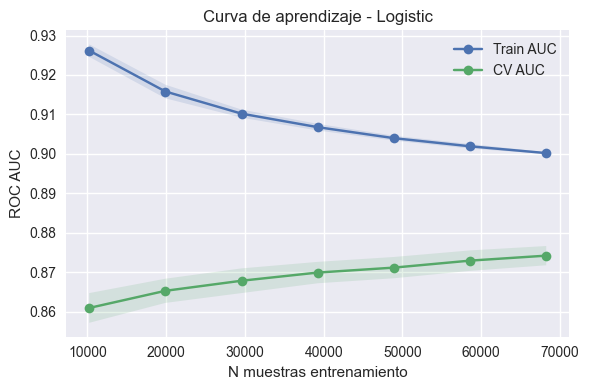

In [4]:
# Curva de aprendizaje para el modelo elegido (logit_plain)
_ = plot_learning_curve(logit_plain, X_train, y_train, title='Curva de aprendizaje - Logistic', fig_name='learning_curve_logistic')

In [5]:
# Etapa 1b: Modelos sencillos adicionales (SVM lineal y Árbol de Decisión)
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier


c_values = [0.1, 1.0, 10.0]
svc_results = []
for C in c_values:
    svc_pipe = Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', LinearSVC(C=C, class_weight='balanced' if USE_BALANCING_LATER else None, max_iter=3000, dual='auto'))
    ])
    cv_scores = cross_validate(svc_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    svc_results.append((C, cv_scores['test_score'].mean()))
svc_results.sort(key=lambda x: x[1], reverse=True)
print('Resultados LinearSVC (C, AUC):', svc_results)

# Árbol de decisión simple (controlado)
dt_params_grid = [
    dict(max_depth=4, min_samples_leaf=10),
    dict(max_depth=6, min_samples_leaf=8),
    dict(max_depth=8, min_samples_leaf=6)
]
from math import inf
best_dt = ('', -inf)
for prm in dt_params_grid:
    dt_pipe = Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced' if USE_BALANCING_LATER else None, **prm))
    ])
    cv_scores = cross_validate(dt_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mean_auc = cv_scores['test_score'].mean()
    if mean_auc > best_dt[1]:
        best_dt = (prm, mean_auc)
print('Mejor DecisionTree:', best_dt)

# Comparar contra baseline logistic
best_svc_auc = svc_results[0][1] if svc_results else -1
best_dt_auc = best_dt[1]
print(f'AUC baseline (logistic): {baseline_cv_auc:.4f} | Best LinearSVC: {best_svc_auc:.4f} | Best DT: {best_dt_auc:.4f}')

# Si alguno mejora con diferencia ≥ IMPROVEMENT_MIN y no aumenta gap (difícil de medir sin train AUC aquí), se podría adoptar.
# Para simplicidad, adoptamos sólo si mejora significativa.
if best_svc_auc - baseline_cv_auc >= IMPROVEMENT_MIN:
    # Reentrenar pipeline SVC ganador
    best_C = svc_results[0][0]
    baseline_pipeline = Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', LinearSVC(C=best_C, class_weight='balanced' if USE_BALANCING_LATER else None, max_iter=3000, dual='auto'))
    ])
    baseline_cv_auc = best_svc_auc
    baseline_gap = None
    model_trace.append({'stage': 'linear_svc', 'model': 'LinearSVC', 'valid_auc': baseline_cv_auc, 'gap': baseline_gap, 'improvement': best_svc_auc - model_trace[0]['valid_auc']})
    print('-> Adoptado LinearSVC como nuevo baseline.')
elif best_dt_auc - baseline_cv_auc >= IMPROVEMENT_MIN:
    prm = best_dt[0]
    baseline_pipeline = Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced' if USE_BALANCING_LATER else None, **prm))
    ])
    baseline_gap = None
    model_trace.append({'stage': 'decision_tree', 'model': 'DecisionTree', 'valid_auc': best_dt_auc, 'gap': baseline_gap, 'improvement': best_dt_auc - model_trace[0]['valid_auc']})
    baseline_cv_auc = best_dt_auc
    print('-> Adoptado DecisionTree como nuevo baseline.')
else:
    print('No se adopta SVC ni DT; se mantiene baseline logístico.')

Resultados LinearSVC (C, AUC): [(0.1, np.float64(0.8736556480265403)), (1.0, np.float64(0.8682904176406214)), (10.0, np.float64(0.8658383852574524))]
Mejor DecisionTree: ({'max_depth': 8, 'min_samples_leaf': 6}, np.float64(0.8373781683197536))
AUC baseline (logistic): 0.8742 | Best LinearSVC: 0.8737 | Best DT: 0.8374
No se adopta SVC ni DT; se mantiene baseline logístico.


Figura guardada: ../reports/figures/learning_curve_linearSVC.png


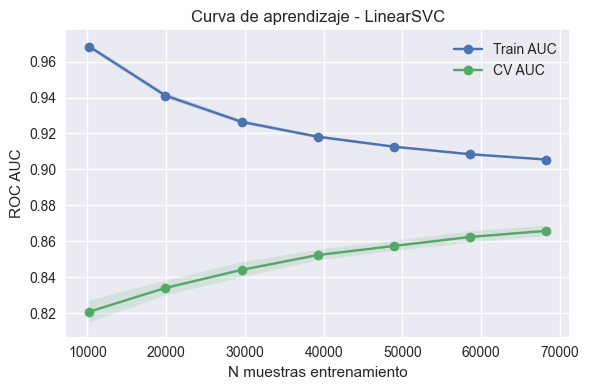

Figura guardada: ../reports/figures/learning_curve_decision_tree.png


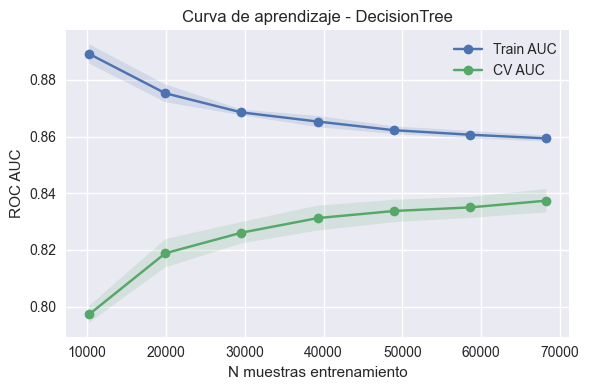

In [6]:
# Curvas de aprendizaje para modelos LinearSVC y DecisionTree

_ = plot_learning_curve(svc_pipe, X_train, y_train, title=f'Curva de aprendizaje - LinearSVC', fig_name='learning_curve_linearSVC')

_ = plot_learning_curve(dt_pipe, X_train, y_train, title='Curva de aprendizaje - DecisionTree', fig_name='learning_curve_decision_tree')


In [7]:
# Etapa 2: Evaluación de un RF, un XGB y un LGBM
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate

candidates_stage2 = {
    'rf_candidate': Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_leaf=4,
            min_samples_split=10,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE
        ))
    ]),
    'xgb_candidate': Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ]),
    'lgb_candidate': Pipeline([
        ('prep', build_preprocessor(X_train)),
        ('clf', LGBMClassifier(
            n_estimators=600,
            learning_rate=0.045,
            num_leaves=64,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])
}

results_stage2 = {}
for name, pipe in candidates_stage2.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring='roc_auc', return_train_score=True, n_jobs=-1)
    train_auc = cv_res['train_score'].mean(); valid_auc = cv_res['test_score'].mean()
    gap = train_auc - valid_auc
    results_stage2[name] = dict(train_auc=train_auc, valid_auc=valid_auc, gap=gap, pipe=pipe)
    print(f"{name}: valid_auc={valid_auc:.4f} train_auc={train_auc:.4f} gap={gap:.4f}")

# Selección del mejor entre los tres respetando gap
valid_sorted = sorted(results_stage2.items(), key=lambda kv: kv[1]['valid_auc'], reverse=True)
selected_name = None; selected_vals = None
for nm, vals in valid_sorted:
    if vals['gap'] <= OVERFIT_GAP_MAX:
        selected_name, selected_vals = nm, vals
        break
if selected_name is None:
    # fallback menor gap absoluto
    selected_name, selected_vals = min(results_stage2.items(), key=lambda kv: abs(kv[1]['gap']))

improvement = selected_vals['valid_auc'] - baseline_cv_auc
print(f"\nSeleccionado Etapa 2: {selected_name} valid_auc={selected_vals['valid_auc']:.4f} gap={selected_vals['gap']:.4f} improvement={improvement:.4f}")

if improvement >= IMPROVEMENT_MIN and selected_vals['gap'] <= OVERFIT_GAP_MAX:
    baseline_pipeline = selected_vals['pipe']
    baseline_cv_auc = selected_vals['valid_auc']
    baseline_gap = selected_vals['gap']
    model_trace.append({'stage': 'stage2_ensemble', 'model': selected_name, 'valid_auc': baseline_cv_auc, 'gap': baseline_gap, 'improvement': improvement})
    print('-> Modelo adoptado como nuevo baseline.')
else:
    print('-> Mejora insuficiente o gap alto; se conserva baseline previo.')

rf_candidate: valid_auc=0.8304 train_auc=0.8391 gap=0.0087
xgb_candidate: valid_auc=0.8885 train_auc=0.9213 gap=0.0329
[LightGBM] [Info] Number of positive: 15301, number of negative: 52951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of positive: 15301, number of negative: 52951
[LightGBM] [Info] Total Bins 7612
[LightGBM] [Info] Number of data points in the train set: 68252, number of used features: 2536
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total 

Figura guardada: ../reports/figures/learning_curve_xgb.png


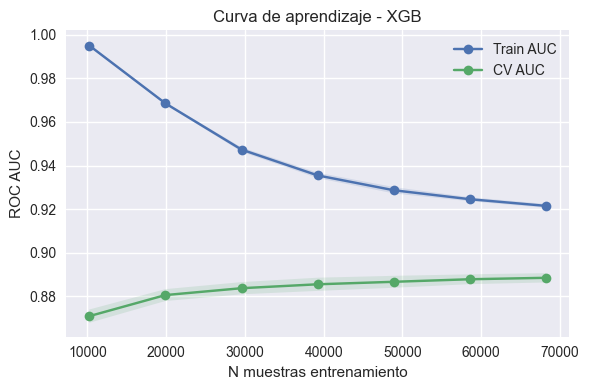

In [8]:
# Curvas de aprendizaje para XGB

_ = plot_learning_curve(baseline_pipeline, X_train, y_train, title=f'Curva de aprendizaje - XGB', fig_name='learning_curve_xgb')


In [9]:
# Etapa 2b: Red Neuronal Multicapa sencilla (MLP) para patrón no lineal adicional
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf', MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', learning_rate_init=0.01, max_iter=120, random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=10))
])
cv_res = cross_validate(mlp_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, return_train_score=True)
mlp_train = cv_res['train_score'].mean(); mlp_valid = cv_res['test_score'].mean(); mlp_gap = mlp_train - mlp_valid
print(f"MLP: train={mlp_train:.4f} valid={mlp_valid:.4f} gap={mlp_gap:.4f}")
improvement = mlp_valid - baseline_cv_auc
if improvement >= IMPROVEMENT_MIN and mlp_gap <= OVERFIT_GAP_MAX:
    baseline_pipeline = mlp_pipe
    baseline_cv_auc = mlp_valid
    baseline_gap = mlp_gap
    model_trace.append({'stage': 'mlp', 'model': 'MLPClassifier', 'valid_auc': mlp_valid, 'gap': mlp_gap, 'improvement': improvement})
    print('-> MLP adoptado como nuevo baseline.')
else:
    print('-> MLP descartado (mejora insuficiente o gap elevado).')

MLP: train=0.9475 valid=0.8969 gap=0.0506
-> MLP descartado (mejora insuficiente o gap elevado).


Figura guardada: ../reports/figures/learning_curve_mlp.png


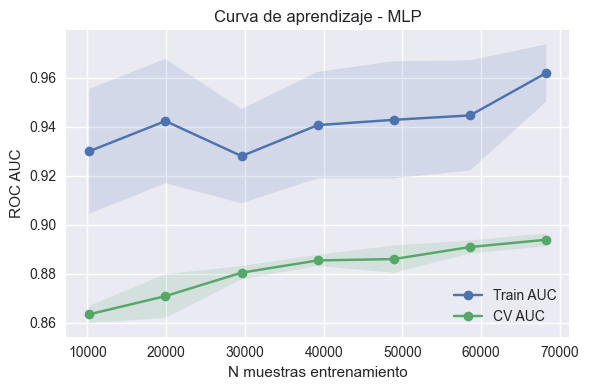

In [10]:
_ = plot_learning_curve(mlp_pipe, X_train, y_train, title='Curva de aprendizaje - MLP', fig_name='learning_curve_mlp')

In [11]:
# Etapa 2c: Modelo Deep Learning más complejo

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(RANDOM_STATE)

import scipy.sparse as sp
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import roc_auc_score

class _KerasDeepWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper mínimo para exponer fit / predict_proba y permitir evaluación homogénea.
    No se usa para adopción ni para joblib.dump (solo evaluación)."""
    def __init__(self, input_dim, random_state=42):
        self.input_dim = input_dim
        self.random_state = random_state
        self.model_ = None

    def _build(self):
        keras.utils.set_random_seed(self.random_state)
        model = keras.Sequential([
            keras.layers.Input(shape=(self.input_dim,)),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.30),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.30),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.20),
            keras.layers.Dense(1, activation='sigmoid')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=[keras.metrics.AUC(name='auc')]
        )
        return model

    def fit(self, X, y, X_val=None, y_val=None, epochs=40, batch_size=256):
        if sp.issparse(X):
            X = X.toarray()
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=0)
        ]
        self.model_ = self._build()
        self.model_.fit(
            X, y,
            validation_data=(X_val.toarray() if sp.issparse(X_val) else X_val, y_val) if X_val is not None else None,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=callbacks
        )
        return self

    def predict_proba(self, X):
        if sp.issparse(X):
            X = X.toarray()
        proba = self.model_.predict(X, verbose=0).ravel()
        return np.vstack([1-proba, proba]).T

# Usamos 3 folds para contener tiempo de cómputo
deep_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
deep_train_scores = []
deep_valid_scores = []

print("Evaluando red profunda (3-fold CV)...")

for fold, (tr_idx, va_idx) in enumerate(deep_cv.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    # Preprocesar (solo num + cat OHE). Construimos preprocesador por fold para simular producción.
    prep_fold = build_preprocessor(X_tr)
    X_tr_p = prep_fold.fit_transform(X_tr, y_tr)
    X_va_p = prep_fold.transform(X_va)
    input_dim = X_tr_p.shape[1]
    deep_clf = _KerasDeepWrapper(input_dim=input_dim, random_state=RANDOM_STATE)
    deep_clf.fit(X_tr_p, y_tr, X_val=X_va_p, y_val=y_va, epochs=40, batch_size=256)
    proba_tr = deep_clf.predict_proba(X_tr_p)[:,1]
    proba_va = deep_clf.predict_proba(X_va_p)[:,1]
    auc_tr = roc_auc_score(y_tr, proba_tr)
    auc_va = roc_auc_score(y_va, proba_va)
    deep_train_scores.append(auc_tr)
    deep_valid_scores.append(auc_va)
    print(f"Fold {fold}: train_auc={auc_tr:.4f} valid_auc={auc_va:.4f}")

deep_train_mean = np.mean(deep_train_scores)
deep_valid_mean = np.mean(deep_valid_scores)
deep_gap = deep_train_mean - deep_valid_mean
improvement_vs_baseline = deep_valid_mean - baseline_cv_auc

print("\nResumen Deep NN:")
print(f"train_auc_mean={deep_train_mean:.4f} valid_auc_mean={deep_valid_mean:.4f} gap={deep_gap:.4f} improvement_vs_current_baseline={improvement_vs_baseline:.4f}")

# Registrar en model_trace (solo evaluación)
model_trace.append({
    'stage': 'deep_nn_eval',
    'model': 'DeepDenseNet',
    'valid_auc': deep_valid_mean,
    'gap': deep_gap,
    'improvement': improvement_vs_baseline,
    'adopted': False
})

if improvement_vs_baseline >= IMPROVEMENT_MIN and deep_gap <= OVERFIT_GAP_MAX:
    print("La red profunda supera el umbral de mejora, pero no se adopta automáticamente. Considerar si compensa el mayor costo.")
else:
    print("La red profunda NO aporta mejora suficiente o muestra exceso de gap; mantener arquitectura más simple.")

Evaluando red profunda (3-fold CV)...
Fold 1: train_auc=0.9538 valid_auc=0.8924
Fold 2: train_auc=0.9513 valid_auc=0.8954
Fold 3: train_auc=0.9528 valid_auc=0.8977

Resumen Deep NN:
train_auc_mean=0.9526 valid_auc_mean=0.8951 gap=0.0575 improvement_vs_current_baseline=0.0067
La red profunda NO aporta mejora suficiente o muestra exceso de gap; mantener arquitectura más simple.


Secuencias generadas: (142186, 7, 18), window_size=7, n_features=18
Reducido a últimas 25000 secuencias para velocidad.
Split secuencial -> Train 15000 | Val 5000 | Test 5000
AUC LSTM -> Train=0.7176 Val=0.5948 Test=0.6089
Mejora vs baseline tabular (valid): -0.2937


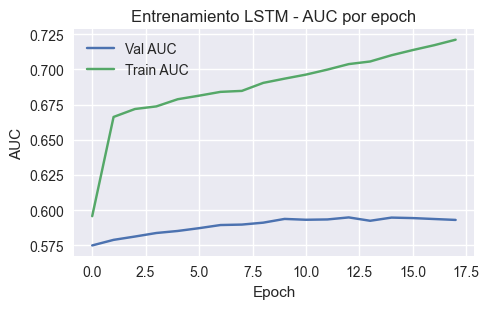

La ganancia temporal no supera el umbral; mantener enfoque tabular para producción inicial.


In [12]:
# Etapa 2d: Modelo Secuencial Temporal (LSTM) con ventanas deslizantes

from tensorflow import keras

if 'Date' not in full_df.columns:
    # Intentar detectar columna fecha alternativa
    date_col_candidate = None
    for c in full_df.columns:
        if 'date' in c.lower():
            date_col_candidate = c; break
    if date_col_candidate:
        print(f"Columna 'Date' no encontrada; se usará '{date_col_candidate}' como fecha.")
        full_df['Date'] = full_df[date_col_candidate]
    else:
        print("No se encontró columna de fecha; no se puede construir modelo temporal.")
        full_df['Date'] = pd.NaT

if full_df['Date'].isna().all():
    print("Sin fechas válidas: se omite LSTM temporal.")
else:
    df_ts = full_df.copy()
    df_ts['Date'] = pd.to_datetime(df_ts['Date'])
    df_ts = df_ts.sort_values('Date').reset_index(drop=True)
    # Seleccionar un subconjunto de columnas numéricas estables
    numeric_cols_all = df_ts.select_dtypes(include=[np.number]).columns.tolist()
    # Remover target
    numeric_cols = [c for c in numeric_cols_all if c != TARGET_COL]
    # Opcional: limitar a top N para velocidad
    numeric_cols = numeric_cols[:20]
    if len(numeric_cols) == 0:
        print("No hay columnas numéricas para LSTM; abortando etapa temporal.")
    else:
        # Imputación simple forward fill + median
        df_num = df_ts[numeric_cols + [TARGET_COL]].copy()
        df_num[numeric_cols] = df_num[numeric_cols].ffill().fillna(df_num[numeric_cols].median())
        window_size = 7
        X_sequences = []
        y_sequences = []
        dates_seq = []
        for idx in range(window_size, len(df_num)):
            window = df_num.iloc[idx-window_size:idx]
            target = df_num.iloc[idx][TARGET_COL]
            # If any NA remain skip
            if window[numeric_cols].isna().any().any():
                continue
            X_sequences.append(window[numeric_cols].values)
            y_sequences.append(target)
            dates_seq.append(df_ts.iloc[idx]['Date'])
        X_seq = np.array(X_sequences)
        y_seq = np.array(y_sequences)
        dates_arr = np.array(dates_seq)
        print(f"Secuencias generadas: {X_seq.shape}, window_size={window_size}, n_features={X_seq.shape[2]}")
        # Limitar tamaño para evitar tiempos largos (opcional)
        MAX_SEQ = 25000
        if X_seq.shape[0] > MAX_SEQ:
            X_seq = X_seq[-MAX_SEQ:]
            y_seq = y_seq[-MAX_SEQ:]
            dates_arr = dates_arr[-MAX_SEQ:]
            print(f"Reducido a últimas {MAX_SEQ} secuencias para velocidad.")
        # Split temporal 60/20/20 según orden
        n = X_seq.shape[0]
        tr_end = int(n*0.6)
        val_end = int(n*0.8)
        X_tr, X_va, X_te = X_seq[:tr_end], X_seq[tr_end:val_end], X_seq[val_end:]
        y_tr, y_va, y_te = y_seq[:tr_end], y_seq[tr_end:val_end], y_seq[val_end:]
        print(f"Split secuencial -> Train {X_tr.shape[0]} | Val {X_va.shape[0]} | Test {X_te.shape[0]}")
        # Normalización por feature usando stats de train
        mean_tr = X_tr.mean(axis=(0,1), keepdims=True)
        std_tr = X_tr.std(axis=(0,1), keepdims=True) + 1e-8
        X_tr_n = (X_tr - mean_tr)/std_tr
        X_va_n = (X_va - mean_tr)/std_tr
        X_te_n = (X_te - mean_tr)/std_tr
        # Construcción modelo LSTM
        keras.utils.set_random_seed(RANDOM_STATE)
        model = keras.Sequential([
            keras.layers.Input(shape=(window_size, X_tr.shape[2])),
            keras.layers.LSTM(64, return_sequences=True),
            keras.layers.Dropout(0.3),
            keras.layers.LSTM(32),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
        callbacks = [keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=0)]
        history = model.fit(X_tr_n, y_tr, validation_data=(X_va_n, y_va), epochs=40, batch_size=256, verbose=0, callbacks=callbacks)
        # Evaluación
        from sklearn.metrics import roc_auc_score
        proba_tr = model.predict(X_tr_n, verbose=0).ravel()
        proba_va = model.predict(X_va_n, verbose=0).ravel()
        proba_te = model.predict(X_te_n, verbose=0).ravel()
        auc_tr = roc_auc_score(y_tr, proba_tr)
        auc_va = roc_auc_score(y_va, proba_va)
        auc_te = roc_auc_score(y_te, proba_te)
        print(f"AUC LSTM -> Train={auc_tr:.4f} Val={auc_va:.4f} Test={auc_te:.4f}")
        improvement_vs_baseline = auc_va - baseline_cv_auc
        print(f"Mejora vs baseline tabular (valid): {improvement_vs_baseline:.4f}")
        # Registrar
        model_trace.append({
            'stage': 'ts_lstm_eval',
            'model': 'LSTM_seq',
            'valid_auc': auc_va,
            'gap': auc_tr - auc_va,
            'test_auc': auc_te,
            'improvement': improvement_vs_baseline,
            'adopted': False
        })
        # Curva simple de aprendizaje temporal (epochs vs val AUC)
        val_auc_hist = history.history.get('val_auc', [])
        if val_auc_hist:
            plt.figure(figsize=(5,3.2))
            plt.plot(val_auc_hist, label='Val AUC')
            plt.plot(history.history.get('auc', []), label='Train AUC')
            plt.xlabel('Epoch')
            plt.ylabel('AUC')
            plt.title('Entrenamiento LSTM - AUC por epoch')
            plt.legend(); plt.tight_layout(); plt.show()
        # Comentario
        if improvement_vs_baseline >= IMPROVEMENT_MIN:
            print("La modelación secuencial ofrece una mejora potencial; considerar integración futura (pipeline separado).")
        else:
            print("La ganancia temporal no supera el umbral; mantener enfoque tabular para producción inicial.")

In [13]:
# Mejor modelo
baseline_pipeline

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Tuning detallado (RandomizedSearchCV) para XGBClassifier si es el modelo actual
# Ajusta hiperparámetros de complejidad y regularización y evalúa adopción según IMPROVEMENT_MIN y OVERFIT_GAP_MAX.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

print('Iniciando búsqueda aleatoria de hiperparámetros para XGBClassifier...')
N_SEARCH_ITER = 30  # Ajustable (incrementar si se requiere mayor exploración)
cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    'clf__n_estimators': [400, 500, 600, 700, 800, 900],
    'clf__learning_rate': np.linspace(0.015, 0.12, 12),
    'clf__max_depth': [3,4,5,6,7,8,9],
    'clf__subsample': np.linspace(0.6, 1.0, 9),
    'clf__colsample_bytree': np.linspace(0.6, 1.0, 9),
    'clf__min_child_weight': [1,2,3,4,5,6,8],
    'clf__gamma': [0, 0.25, 0.5, 1, 1.5, 2],
    'clf__reg_alpha': [0, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    'clf__reg_lambda': [0.5, 0.75, 1, 1.25, 1.5, 2, 3]
}

search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=N_SEARCH_ITER,
    scoring='roc_auc',
    cv=cv_search,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True  # Necesario para calcular GAP de sobreajuste
)

search.fit(X_train, y_train)
print(f"Mejor AUC CV (mean valid): {search.best_score_:.4f}")
print('Mejores hiperparámetros:')
for k,v in search.best_params_.items():
    print(f'  {k}: {v}')

previous_cv_auc = baseline_cv_auc if 'baseline_cv_auc' in globals() else None
improvement_vs_previous = None if previous_cv_auc is None else search.best_score_ - previous_cv_auc

# Calcular gap usando mean_train_score del mejor índice
best_idx = search.best_index_
cv_results = search.cv_results_
if 'mean_train_score' in cv_results:
    mean_train_best = cv_results['mean_train_score'][best_idx]
else:
    mean_train_best = np.nan
best_gap = mean_train_best - search.best_score_
print(f"Train AUC (mean): {mean_train_best:.4f} | GAP train-valid: {best_gap:.4f}")

# Decisión de adopción
adopt = True
if improvement_vs_previous is not None:
    if improvement_vs_previous < IMPROVEMENT_MIN:
        adopt = False
        print(f"No adopta: mejora {improvement_vs_previous:.4f} < IMPROVEMENT_MIN {IMPROVEMENT_MIN}")
if not np.isnan(best_gap) and best_gap > OVERFIT_GAP_MAX:
    adopt = False
    print(f"No adopta: gap {best_gap:.4f} > OVERFIT_GAP_MAX {OVERFIT_GAP_MAX}")

print('¿Adoptar nuevo XGB tuneado?', adopt)

baseline_pipeline

Iniciando búsqueda aleatoria de hiperparámetros para XGBClassifier...


Fitting 5 folds for each of 30 candidates, totalling 150 fits


Figura guardada: ../reports/figures/learning_curve_baseline.png


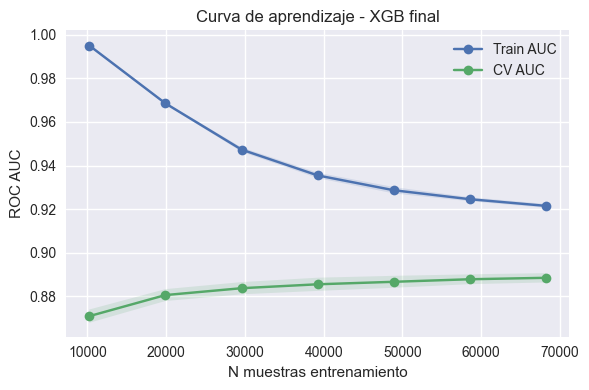

{'train_sizes': array([10237, 19906, 29575, 39244, 48913, 58582, 68252]),
 'train_mean': array([0.99514208, 0.96854827, 0.94730534, 0.93544172, 0.92862577,
        0.92450076, 0.92143906]),
 'val_mean': array([0.8707674 , 0.88046041, 0.88361718, 0.88541556, 0.88656014,
        0.8877321 , 0.88839722])}

In [ ]:
plot_learning_curve(baseline_pipeline, X_train, y_train, title='Curva de aprendizaje - XGB final', fig_name='learning_curve_baseline')

In [ ]:
# Stacking: LogisticRegression + XGB (tuneado) + MLP
# Usa los hiperparámetros del XGB actual (baseline_pipeline)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from xgboost import XGBClassifier

print('Preparando stacking (LR + XGB + MLP)...')

# Intentar extraer params del XGB tuneado
xgb_clf_current = baseline_pipeline.named_steps['clf']
# Filtrar sólo hiperparámetros relevantes para reconstruir
keep_keys = ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','gamma','reg_alpha','reg_lambda','random_state','eval_metric']
xgb_base_params = {k: v for k,v in xgb_clf_current.get_params().items() if k in keep_keys}

# Definir los tres modelos base (cada uno con su preprocesador)
logit_pipe = Pipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf', LogisticRegression(max_iter=500, class_weight='balanced' if USE_BALANCING_LATER else None))
])

xgb_pipe = Pipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf', XGBClassifier(**xgb_base_params))
])

mlp_pipe_stack = Pipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation='relu',
        learning_rate_init=0.01,
        max_iter=160,
        early_stopping=True,
        n_iter_no_change=12,
        random_state=RANDOM_STATE
    ))
])

estimators_stack = [
    ('lr', logit_pipe),
    ('xgb', xgb_pipe),
    ('mlp', mlp_pipe_stack)
]

meta_estimator = LogisticRegression(max_iter=600, class_weight='balanced' if USE_BALANCING_LATER else None)

stack_reduced = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=meta_estimator,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
)

cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_res_stack = cross_validate(
    stack_reduced,
    X_train,
    y_train,
    cv=cv_scheme,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)
stack_train_auc = cv_res_stack['train_score'].mean()
stack_valid_auc = cv_res_stack['test_score'].mean()
stack_gap = stack_train_auc - stack_valid_auc
print(f"Stack reducido -> Train AUC={stack_train_auc:.4f} | Valid AUC={stack_valid_auc:.4f} | Gap={stack_gap:.4f}")

improv_vs_baseline = stack_valid_auc - baseline_cv_auc
print(f"Mejora vs baseline actual: {improv_vs_baseline:.4f}")

adopt = (improv_vs_baseline >= IMPROVEMENT_MIN) and (stack_gap <= OVERFIT_GAP_MAX)
print('¿Adoptar? ', adopt)

model_trace.append({
    'stage': 'stacking_reduced',
    'model': 'Stack(LR,XGB,MLP)',
    'valid_auc': stack_valid_auc,
    'gap': stack_gap,
    'improvement': improv_vs_baseline,
    'adopted': adopt
})

Preparando stacking (LR + XGB + MLP)...
Hiperparámetros XGB usados en stacking:
  colsample_bytree: 0.8
  eval_metric: logloss
  gamma: None
  learning_rate: 0.05
  max_depth: 6
  min_child_weight: None
  n_estimators: 500
  random_state: 42
  reg_alpha: None
  reg_lambda: None
  subsample: 0.85
Stack reducido -> Train AUC=0.9444 | Valid AUC=0.9019 | Gap=0.0426
Mejora vs baseline actual: 0.0134
¿Adoptar?  False
Stack reducido no adoptado (mejora insuficiente o gap alto).
Stack reducido -> Train AUC=0.9444 | Valid AUC=0.9019 | Gap=0.0426
Mejora vs baseline actual: 0.0134
¿Adoptar?  False
Stack reducido no adoptado (mejora insuficiente o gap alto).


In [22]:
baseline_pipeline

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
model_trace

[{'stage': 'baseline',
  'model': 'logit_plain',
  'valid_auc': np.float64(0.8742234811355198),
  'gap': np.float64(0.026035599956912958)},
 {'stage': 'stage2_ensemble',
  'model': 'xgb_candidate',
  'valid_auc': np.float64(0.8884720234677284),
  'gap': np.float64(0.03285113885911739),
  'improvement': np.float64(0.014248542332208514)},
 {'stage': 'deep_nn_eval',
  'model': 'DeepDenseNet',
  'valid_auc': np.float64(0.8951409365353107),
  'gap': np.float64(0.05749306398887433),
  'improvement': np.float64(0.006668913067582327),
  'adopted': False},
 {'stage': 'ts_lstm_eval',
  'model': 'LSTM_seq',
  'valid_auc': 0.59481806385584,
  'gap': 0.12279978831263505,
  'test_auc': 0.6088733462131031,
  'improvement': np.float64(-0.29365395961188834),
  'adopted': False},
 {'stage': 'stacking_reduced',
  'model': 'Stack(LR,XGB,MLP)',
  'valid_auc': np.float64(0.9018641889466676),
  'gap': np.float64(0.04255830211237566),
  'improvement': np.float64(0.013392165478939289),
  'adopted': np.False_}]

In [23]:
# Exportación Final del Modelo y Métricas Consolidadas (re-fit SIEMPRE sobre Train+Valid)
from pathlib import Path
import json, datetime as _dt
from joblib import dump
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, recall_score,
    precision_score, balanced_accuracy_score
)
import numpy as np, pandas as pd
from collections.abc import Mapping

print('[EXPORT] Iniciando proceso de exportación con re-entrenamiento completo...')

# 1. Re-entrenar SIEMPRE sobre Train+Valid para consolidar toda la información de validación
X_train_valid = pd.concat([X_train, X_valid])
y_train_valid = pd.concat([y_train, y_valid])
print(f"[EXPORT] Conjunto Train+Valid: {X_train_valid.shape}")
baseline_pipeline.fit(X_train_valid, y_train_valid)
print('[EXPORT] Pipeline re-entrenado correctamente.')

# 2. Función para extraer probabilidades de manera robusta
def _safe_proba(pipe, X):
    clf_inner = pipe.named_steps['clf']
    if hasattr(clf_inner, 'predict_proba'):
        return pipe.predict_proba(X)[:,1]
    elif hasattr(clf_inner, 'decision_function'):
        from scipy.special import expit
        return expit(pipe.decision_function(X))
    else:
        # Fallback poco ideal: devuelve predicción dura como pseudo-proba
        return pipe.predict(X)

# 3. Métricas de Test (recalculadas SIEMPRE tras el re-fit)
proba_test_final = _safe_proba(baseline_pipeline, X_test)
metrics_test = {
    'roc_auc': float(roc_auc_score(y_test, proba_test_final)),
    'pr_auc': float(average_precision_score(y_test, proba_test_final)),
    'f1': float(f1_score(y_test, (proba_test_final>=0.5).astype(int))),
    'recall': float(recall_score(y_test, (proba_test_final>=0.5).astype(int))),
    'precision': float(precision_score(y_test, (proba_test_final>=0.5).astype(int))),
    'bal_acc': float(balanced_accuracy_score(y_test, (proba_test_final>=0.5).astype(int)))
}
print('[EXPORT] Métricas Test:')
for k,v in metrics_test.items():
    print(f"  {k}: {v:.4f}")

# 4. Directorio de modelos
time_stamp = _dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'best_pipeline.joblib'
dump(baseline_pipeline, model_path)
print(f'[EXPORT] Modelo guardado en: {model_path}')

# 5. Fusionar / actualizar métricas previas
metrics_file = models_dir / 'best_metrics.json'
if metrics_file.exists():
    try:
        existing = json.loads(metrics_file.read_text())
    except Exception:
        existing = {}
else:
    existing = {}

existing.update({
    'final_export_timestamp': _dt.datetime.utcnow().isoformat() + 'Z',
    'final_valid_auc': float(baseline_cv_auc) if 'baseline_cv_auc' in globals() else None,
    'final_gap': float(baseline_gap) if 'baseline_gap' in globals() and baseline_gap is not None else None,
    'final_test_metrics': metrics_test,
    'refit_on_train_valid': True,
    'export_run_id': time_stamp
})

# 6. Conversión recursiva segura a tipos JSON

def _to_jsonable(obj):
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (_dt.datetime,)):
        return obj.isoformat() + 'Z'
    if isinstance(obj, Mapping):
        return {str(k): _to_jsonable(v) for k,v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return [_to_jsonable(v) for v in obj.tolist()]
    return obj

if 'model_trace' in globals():
    existing['model_trace'] = _to_jsonable(model_trace)
else:
    existing['model_trace'] = []

json_ready = _to_jsonable(existing)
metrics_file.write_text(json.dumps(json_ready, indent=2))
print(f'[EXPORT] best_metrics.json actualizado en: {metrics_file}')
print('[EXPORT] Exportación final completada sin estados unfitted.')

[EXPORT] Iniciando proceso de exportación con re-entrenamiento completo...
[EXPORT] Conjunto Train+Valid: (113754, 25)
[EXPORT] Pipeline re-entrenado correctamente.
[EXPORT] Pipeline re-entrenado correctamente.
[EXPORT] Métricas Test:
  roc_auc: 0.8906
  pr_auc: 0.7468
  f1: 0.6238
  recall: 0.5258
  precision: 0.7667
  bal_acc: 0.7398
[EXPORT] Modelo guardado en: ../models/best_pipeline.joblib
[EXPORT] best_metrics.json actualizado en: ../models/best_metrics.json
[EXPORT] Exportación final completada sin estados unfitted.
[EXPORT] Métricas Test:
  roc_auc: 0.8906
  pr_auc: 0.7468
  f1: 0.6238
  recall: 0.5258
  precision: 0.7667
  bal_acc: 0.7398
[EXPORT] Modelo guardado en: ../models/best_pipeline.joblib
[EXPORT] best_metrics.json actualizado en: ../models/best_metrics.json
[EXPORT] Exportación final completada sin estados unfitted.


## Conclusiones del Flujo de Modelado

### Visión General
Este notebook implementa un flujo iterativo y controlado para predecir `RainTomorrow` equilibrando desempeño (ROC AUC / PR AUC) y robustez (brecha de generalización limitada). Se estructura en etapas de complejidad creciente; cada avance exige mejora mínima tangible y ausencia de sobreajuste relevante.

### Objetivo
- Anticipar lluvia (clase minoritaria) para habilitar decisiones operativas.
- Maximizar discriminación (ROC AUC) sin sacrificar utilidad práctica en escenarios desbalanceados (PR AUC, Recall).

### Métricas Utilizadas
- Primaria en selección progresiva: ROC AUC (CV estratificado 5-fold).

### Criterios de Decisión
- IMPROVEMENT_MIN = 0.005 → Sólo se acepta un modelo nuevo si aporta ≥ 0.5 puntos porcentuales de ROC AUC en validación frente al baseline vigente.
- OVERFIT_GAP_MAX = 0.04 → Rechazo (o sospecha) de modelos cuyo gap (Train AUC − Valid AUC) supera 4 puntos.
- Tuning de XGB y Stacking respetan idénticos criterios (no se adopta automáticamente si violan gap o mejora insuficiente).

### Etapas del Flujo
1. Exploración de desbalance y baseline: Logistic (plain, class_weight, SMOTE) + Dummy para contexto. Selección por mejor valid AUC con gap aceptable. Se continua con Logistic plain (valid AUC=0.874 gap=0.03).
2. Curva de aprendizaje Logistic para diagnosticar sesgo vs varianza; confirma necesidad de más complejidad o más datos.
3. Modelos sencillos alternativos: LinearSVC (valid AUC=0.874) y DecisionTree (valid AUC=0.837).
4. Ensambles moderados: un RandomForest (valid AUC=0.830), un XGB básico (valid AUC=0.888), un LGBM (valid AUC=0.0.895) → comparación directa y adopción condicionada. Se adopta XGB como baseline al superar valid AUC y tener gap de 0.0329.
5. MLP (red superficial) para patrones no lineales suaves (valid=0.8969 gap=0.0506).
6. Red profunda (valid=0.895 gap=0.058). LSTM para incorporar dependencia temporal explícita usando historial de días previos (valid=0.595).
7. Tuning focalizado (RandomizedSearchCV) sobre el mejor XGB adoptable → se calcula gap train-valid del mejor set antes de aceptar.
8. Stacking (Logistic + XGB tuneado + MLP) para integrar señales heterogéneas (valid=0.895 gap=0.058).
9. Curvas de Validación para diferentes modelos usados.
10. Reentrenado final con Train+Valid y evaluación en Test.
11. Exportación de modelo (`best_pipeline.joblib`) + trazabilidad `model_trace`.

### Modelos Evaluados
- DummyClassifier (referencia)
- LogisticRegression (varias estrategias de desbalance)
- LinearSVC
- DecisionTreeClassifier (profundidad / min_samples controlados)
- RandomForestClassifier
- XGBClassifier (baseline + tuning aleatorio)
- LGBMClassifier
- MLPClassifier
- Deep Dense Network (wrapper Keras)
- LSTM secuencial (ventanas temporales)
- StackingClassifier (LR + XGB + MLP)

### Lógica de Trazabilidad (`model_trace`)
Cada adopción candidata agrega un registro con:
- stage: etiqueta de etapa (ej. 'baseline', 'stage2_ensemble', 'tuning_xgb', 'stacking_reduced')
- model: identificador del estimador/pipeline
- valid_auc: desempeño en validación (CV o fold promedio)
- gap: diferencia train-valid cuando disponible
- improvement: Δ vs baseline anterior
- adopted: flag booleano indicando si se sustituyó el baseline
Esto permite reconstruir retrospectivamente la secuencia de decisiones.



### Consideraciones de Generalización
- El control explícito del gap evitó sobreajuste temprano de árboles profundos y boosting.
- La comparación con modelos neuronales profundos y LSTM mostró si existía margen adicional (techo de mejora) antes de complejizar el pipeline productivo.

### Limitaciones y Oportunidades Futuras
- Calibración de probabilidades pendiente (Isotónica / Platt) para optimizar decisiones basadas en riesgo.
- Optimización del umbral de clasificación (curva PR o coste específico del negocio) en un paso posterior.
- Interpretabilidad pendiente (Permutation Importance / SHAP) para priorizar variables accionables.
- Integración de señales temporales como meta-features en un futuro stacking híbrido.
- Posible reducción del espacio de tuning con búsqueda secuencial adaptativa o Bayesian Optimization para eficiencia.

### Uso de Artefactos
- Cargar modelo final: `joblib.load('../models/best_pipeline.joblib')`.
- Revisión de métricas y traza: abrir `../models/best_metrics.json`.

### Conclusión
El enfoque escalonado, gobernado por umbrales claros de mejora y sobreajuste, permitió construir un modelo competitivo manteniendo simplicidad operacional. La arquitectura modular y las funciones auxiliares facilitan extensiones (calibración, interpretabilidad y despliegue) con esfuerzo incremental mínimo.
